In [32]:
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [33]:
import numpy as np
import glob

def load_all_traces(base_path, dtype=np.float32):
    files = sorted(glob.glob(base_path + "trace*.trc"))

    traces = [np.fromfile(f, dtype=dtype) for f in files]

    lengths = [len(t) for t in traces]
    min_len = min(lengths)

    print("Min trace length:", min_len)
    print("Max trace length:", max(lengths))

    # trim all traces to same length
    traces = np.array([t[:min_len] for t in traces])

    return traces

In [73]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

def get_top_leaks_multi_test(root_dir=".", top_x=20):
    all_leaky_data = []

    # 1. Find all output directories containing fvr results
    fvr_dirs = glob.glob(os.path.join(root_dir, "../ELMO/output_*fvr*"))

    for test_dir in fvr_dirs:
        test_name = os.path.basename(test_dir)
        t_stats_path = os.path.join(test_dir, "fixedvsrandomtstatistics.txt")
        
        # ELMO usually stores asmtraces in a subfolder; finding the first trace
        asm_glob = glob.glob(os.path.join(test_dir, "asmoutput", "asmtrace*.txt"))
        
        if not os.path.exists(t_stats_path) or not asm_glob:
            print(f"Skipping {test_name}: Required files missing.")
            continue
            
        asm_trace_path = asm_glob[0]

        # 2. Load T-stats and Assembly
        t_stats = np.abs(np.loadtxt(t_stats_path))
        instructions = []
        with open(asm_trace_path, 'r') as f:
            for line in f:
                if "---" in line:
                    parts = line.split(': ')
                    instr = parts[-1].strip().split(' ', 1)[-1] if len(parts) > 1 else line.strip()
                    instructions.append(instr)
                else:
                    instructions.append(line.strip())

        # 3. Store data with the test name to distinguish origins
        for i in range(min(len(t_stats), len(instructions))):
            # We save (T-stat, Instruction, Cycle, Test Name)
            all_leaky_data.append((t_stats[i], instructions[i], i, test_name))

    # 4. Sort globally by absolute T-statistic
    all_leaky_data.sort(key=lambda x: x[0], reverse=True)
    top_results = all_leaky_data[:top_x]

    # 5. Visualize
    scores = [x[0] for x in top_results][::-1]
    labels = [f"[{x[3]}] Cycle {x[2]}: {x[1]}" for x in top_results][::-1]
get_top_leaks_multi_test()


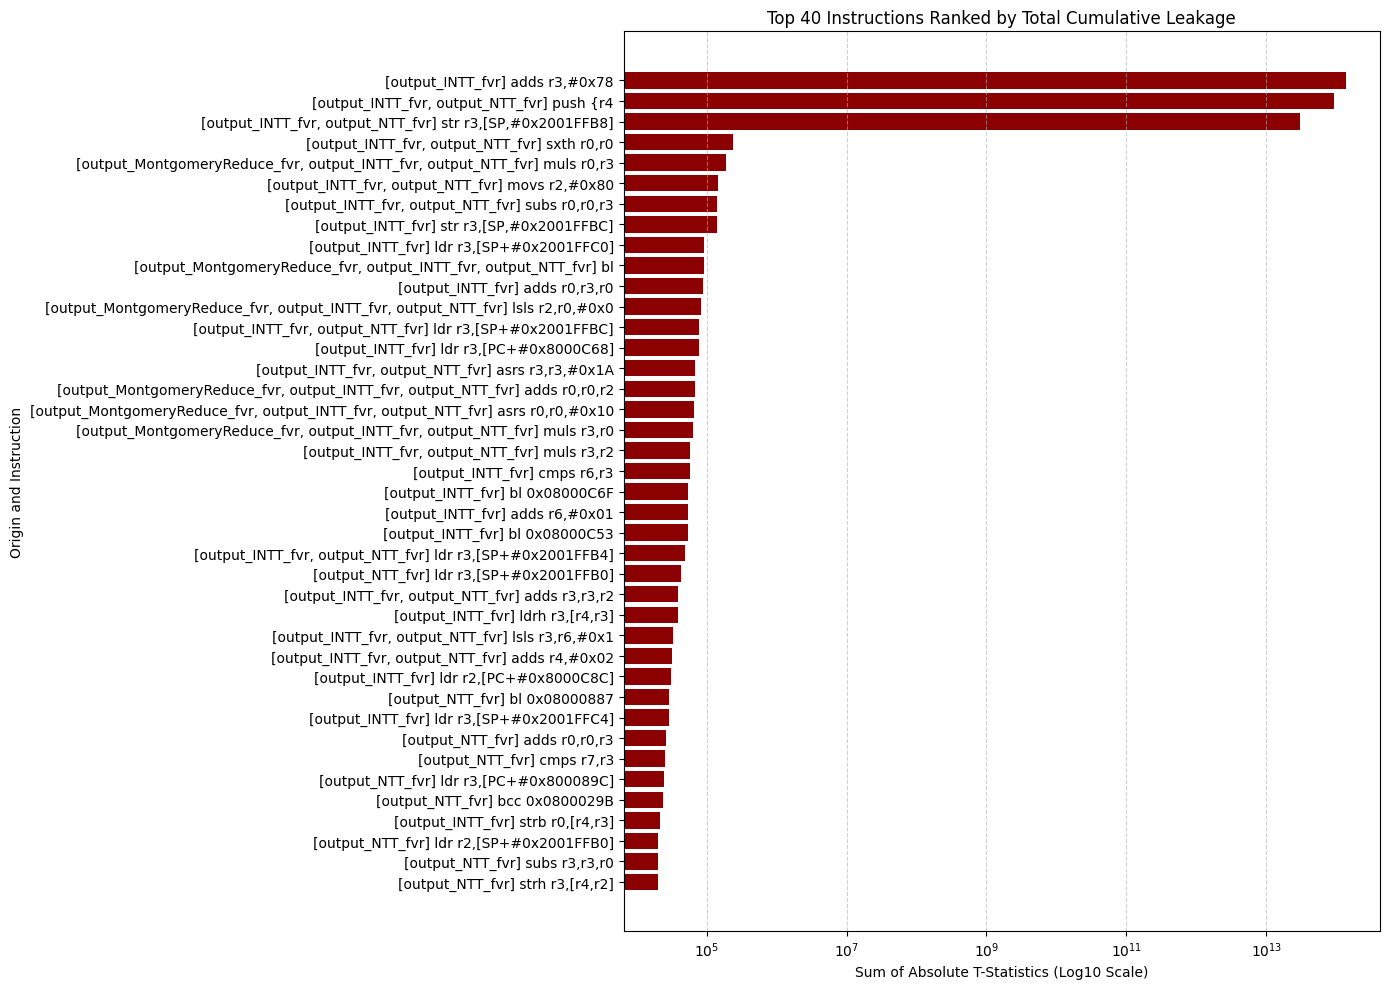

In [79]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_tallied_leaks(root_dir=".", top_x=40):
    # Dictionary to store cumulative absolute T-stats per instruction
    tally = defaultdict(float)
    # Dictionary to track which tests contained the instruction
    origins = defaultdict(set)
    
    fvr_dirs = glob.glob(os.path.join(root_dir, "../ELMO/output_*fvr*"))

    for test_dir in fvr_dirs:
        test_name = os.path.basename(test_dir)
        t_stats_path = os.path.join(test_dir, "fixedvsrandomtstatistics.txt")
        asm_glob = glob.glob(os.path.join(test_dir, "asmoutput", "asmtrace*.txt"))
        
        if not os.path.exists(t_stats_path) or not asm_glob:
            continue
            
        # Load data
        t_stats = np.abs(np.loadtxt(t_stats_path))
        
        instructions = []
        with open(asm_glob[0], 'r') as f:
            for line in f:
                if "---" in line:
                    parts = line.split(': ')
                    instr = parts[-1].strip().split(' ', 1)[-1] if len(parts) > 1 else line.strip()
                    instructions.append(instr)

        # Tally the leakage and record the origin
        for i in range(min(len(t_stats), len(instructions))):
            instr_str = instructions[i]
            tally[instr_str] += t_stats[i]
            origins[instr_str].add(test_name)

    # Sort and take top X
    sorted_tally = sorted(tally.items(), key=lambda x: x[1], reverse=True)[:top_x]
    
    # Create labels that include the origins (joined by commas if multiple)
    # Example: [output_INTT_fvr] adds r0,r3,r0
    labels = []
    for instr, score in sorted_tally:
        origin_str = ", ".join(list(origins[instr]))
        labels.append(f"[{origin_str}] {instr}")
    
    # Reverse for horizontal plotting
    labels = labels[::-1]
    scores = [x[1] for x in sorted_tally][::-1]

    plt.figure(figsize=(14, 10))
    plt.barh(labels, scores, color='darkred')
    
    # Apply Log10 scale to the X-axis
    plt.xscale('log')
    
    plt.title(f"Top {top_x} Instructions Ranked by Total Cumulative Leakage")
    plt.xlabel("Sum of Absolute T-Statistics (Log10 Scale)")
    plt.ylabel("Origin and Instruction")
    plt.grid(axis='x', which='both', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
plot_tallied_leaks()

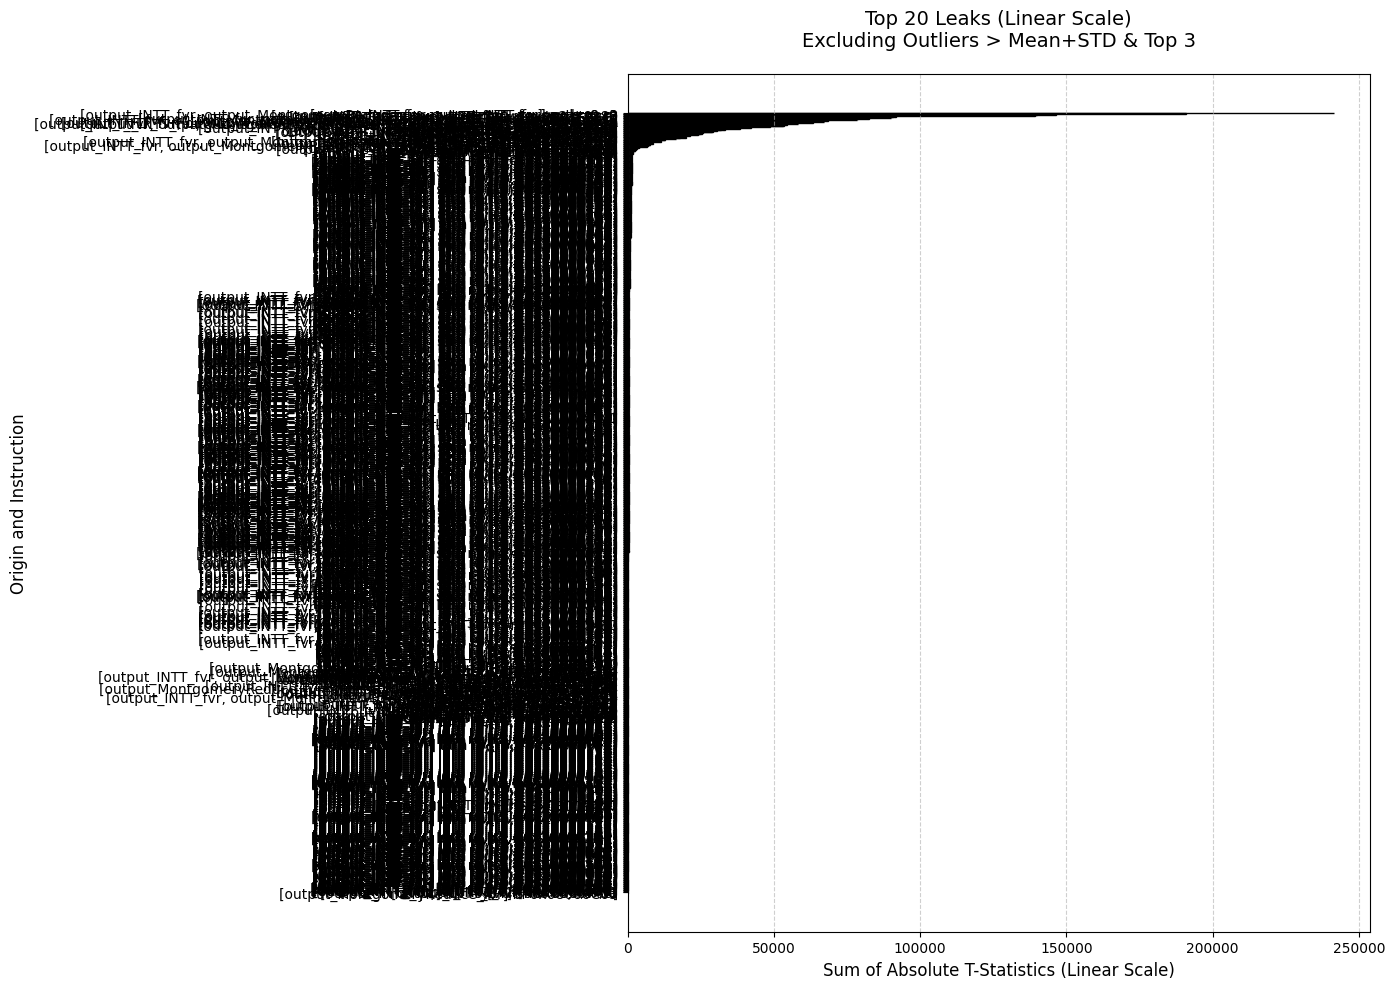

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_tallied_leaks(root_dir=".", top_x=20):
    # Dictionary to store cumulative absolute T-stats per instruction
    tally = defaultdict(float)
    # Dictionary to track which files/tests contained the instruction
    origins = defaultdict(set)
    
    fvr_dirs = glob.glob(os.path.join(root_dir, "../ELMO/output_*fvr*"))

    for test_dir in fvr_dirs:
        test_name = os.path.basename(test_dir)
        t_stats_path = os.path.join(test_dir, "fixedvsrandomtstatistics.txt")
        asm_glob = glob.glob(os.path.join(test_dir, "asmoutput", "asmtrace*.txt"))
        
        if not os.path.exists(t_stats_path) or not asm_glob:
            continue
            
        t_stats = np.abs(np.loadtxt(t_stats_path))
        
        instructions = []
        with open(asm_glob[0], 'r') as f:
            for line in f:
                if "---" in line:
                    parts = line.split(': ')
                    instr = parts[-1].strip().split(' ', 1)[-1] if len(parts) > 1 else line.strip()
                    instructions.append(instr)

        for i in range(min(len(t_stats), len(instructions))):
            instr_str = instructions[i]
            tally[instr_str] += t_stats[i]
            origins[instr_str].add(test_name)

    if not tally:
        print("No data found.")
        return

    # --- Statistical Outlier Removal ---
    # We use Mean and Variance (Standard Deviation) to find the "Top Leakers"
    all_scores = np.array(list(tally.values()))
    mean_val = np.mean(all_scores)
    std_val = np.std(all_scores) # Square root of Variance
    
    # Define a threshold (anything above this is considered an extreme outlier)
    # Adjust the multiplier (e.g., 1.0 or 2.0) to change how aggressive the removal is
    outlier_threshold = mean_val + (1.0 * std_val)

    # Filter out items that are significantly higher than the average
    filtered_items = [item for item in tally.items() if item[1] <= outlier_threshold]
    
    # Sort remaining items by score descending
    filtered_items.sort(key=lambda x: x[1], reverse=True)

    # Take the top_x from the remaining valid instructions
    final_items = filtered_items[:top_x]
    
    if not final_items:
        print("Filtering was too aggressive. No data left.")
        return

    # Format labels and scores
    labels = []
    for instr, score in final_items:
        origin_str = ", ".join(sorted(list(origins[instr])))
        labels.append(f"[{origin_str}] {instr}")
    
    # Reverse for horizontal bar chart display
    labels = labels[::-1]
    scores = [x[1] for x in final_items][::-1]

    # --- Visualize (Linear Scale) ---
    plt.figure(figsize=(14, 10))
    plt.barh(labels

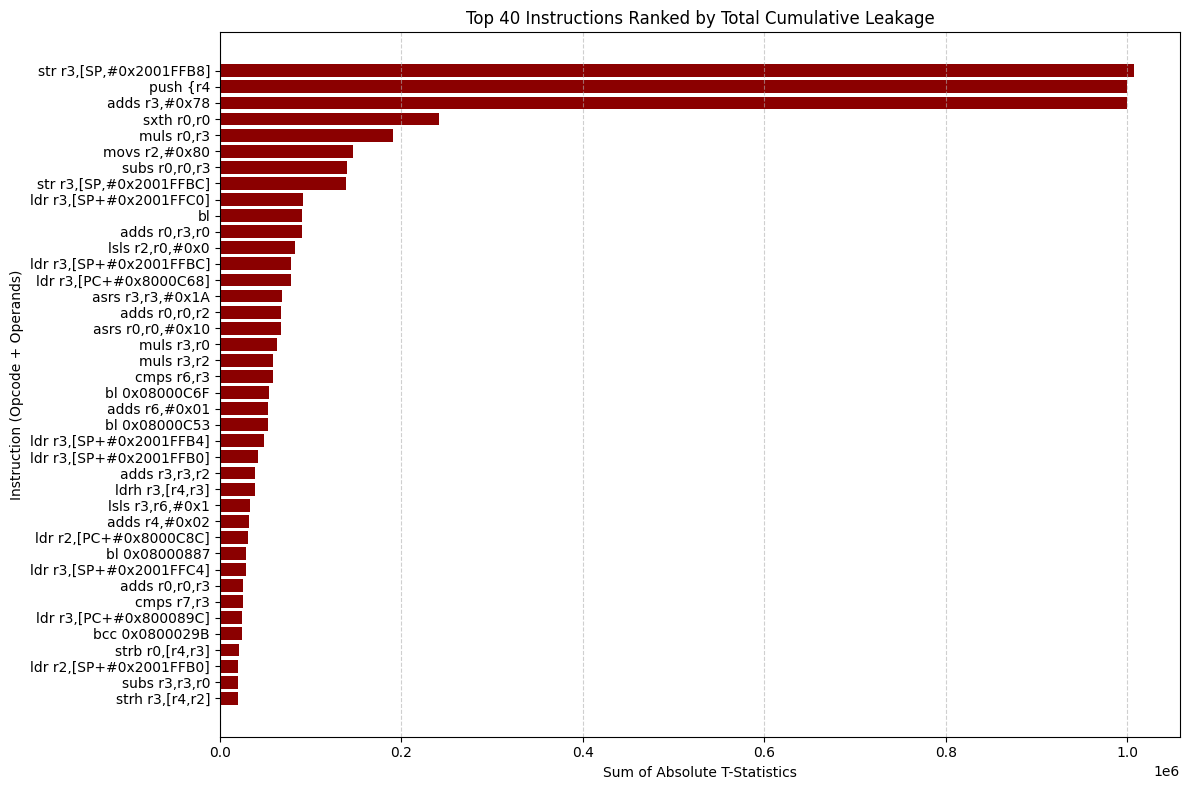

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_tallied_leaks(root_dir=".", top_x=20):
    # Dictionary to store cumulative absolute T-stats per instruction
    tally = defaultdict(float)
    
    fvr_dirs = glob.glob(os.path.join(root_dir, "../ELMO/output_*fvr*"))

    for test_dir in fvr_dirs:
        t_stats_path = os.path.join(test_dir, "fixedvsrandomtstatistics.txt")
        asm_glob = glob.glob(os.path.join(test_dir, "asmoutput", "asmtrace*.txt"))
        
        if not os.path.exists(t_stats_path) or not asm_glob:
            continue
            
        # Load data, capping extreme outliers to prevent graph distortion
        t_stats = np.abs(np.loadtxt(t_stats_path))
        t_stats = np.clip(t_stats, 0, 1e6) 
        
        instructions = []
        with open(asm_glob[0], 'r') as f:
            for line in f:
                if "---" in line:
                    parts = line.split(': ')
                    instr = parts[-1].strip().split(' ', 1)[-1] if len(parts) > 1 else line.strip()
                    instructions.append(instr)

        # Tally the leakage per unique instruction string
        for i in range(min(len(t_stats), len(instructions))):
            tally[instructions[i]] += t_stats[i]

    # Sort and take top X
    sorted_tally = sorted(tally.items(), key=lambda x: x[1], reverse=True)[:top_x]
    
    labels = [x[0] for x in sorted_tally][::-1]
    scores = [x[1] for x in sorted_tally][::-1]

    plt.figure(figsize=(12, 8))
    plt.barh(labels, scores, color='darkred')
    plt.title(f"Top {top_x} Instructions Ranked by Total Cumulative Leakage")
    plt.xlabel("Sum of Absolute T-Statistics")
    plt.ylabel("Instruction (Opcode + Operands)")
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Run the tally
plot_tallied_leaks(top_x=40)

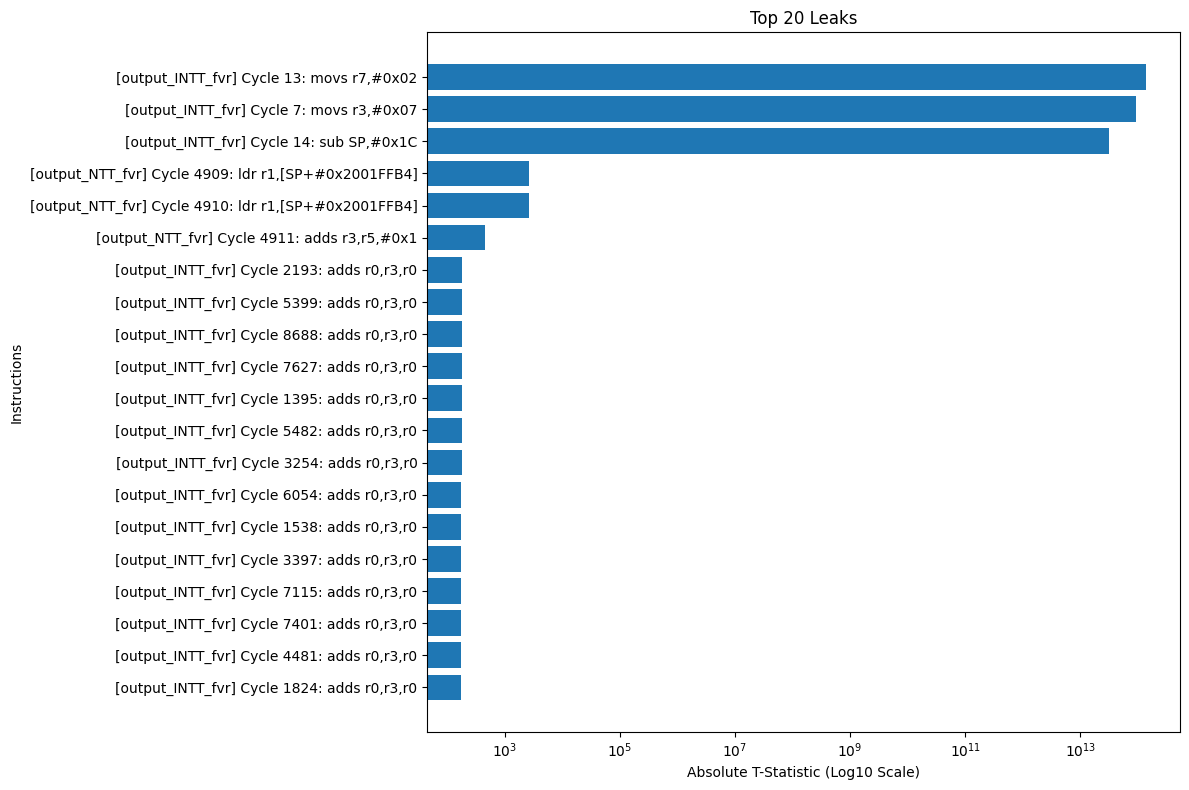

In [70]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

def get_top_leaks_multi_test(root_dir=".", top_x=20):
    all_leaky_data = []

    # 1. Find all output directories containing fvr results
    fvr_dirs = glob.glob(os.path.join(root_dir, "../ELMO/output_*fvr*"))

    for test_dir in fvr_dirs:
        test_name = os.path.basename(test_dir)
        t_stats_path = os.path.join(test_dir, "fixedvsrandomtstatistics.txt")
        
        # ELMO usually stores asmtraces in a subfolder; finding the first trace
        asm_glob = glob.glob(os.path.join(test_dir, "asmoutput", "asmtrace*.txt"))
        
        if not os.path.exists(t_stats_path) or not asm_glob:
            print(f"Skipping {test_name}: Required files missing.")
            continue
            
        asm_trace_path = asm_glob[0]

        # 2. Load T-stats and Assembly
        t_stats = np.abs(np.loadtxt(t_stats_path))
        instructions = []
        with open(asm_trace_path, 'r') as f:
            for line in f:
                if "---" in line:
                    parts = line.split(': ')
                    instr = parts[-1].strip().split(' ', 1)[-1] if len(parts) > 1 else line.strip()
                    instructions.append(instr)
                else:
                    instructions.append(line.strip())

        # 3. Store data with the test name to distinguish origins
        for i in range(min(len(t_stats), len(instructions))):
            # We save (T-stat, Instruction, Cycle, Test Name)
            all_leaky_data.append((t_stats[i], instructions[i], i, test_name))

    # 4. Sort globally by absolute T-statistic
    all_leaky_data.sort(key=lambda x: x[0], reverse=True)
    top_results = all_leaky_data[:top_x]

    # 5. Visualize
    scores = [x[0] for x in top_results][::-1]
    labels = [f"[{x[3]}] Cycle {x[2]}: {x[1]}" for x in top_results][::-1]

    plt.figure(figsize=(12, 8))
    plt.barh(labels, scores)
    plt.xscale('log')
    plt.xlabel('Absolute T-Statistic (Log10 Scale)')
    plt.ylabel('Instructions')
    plt.title(f'Top {top_x} Leaks')
    plt.tight_layout()
    plt.show()
get_top_leaks_multi_test()

# NTT

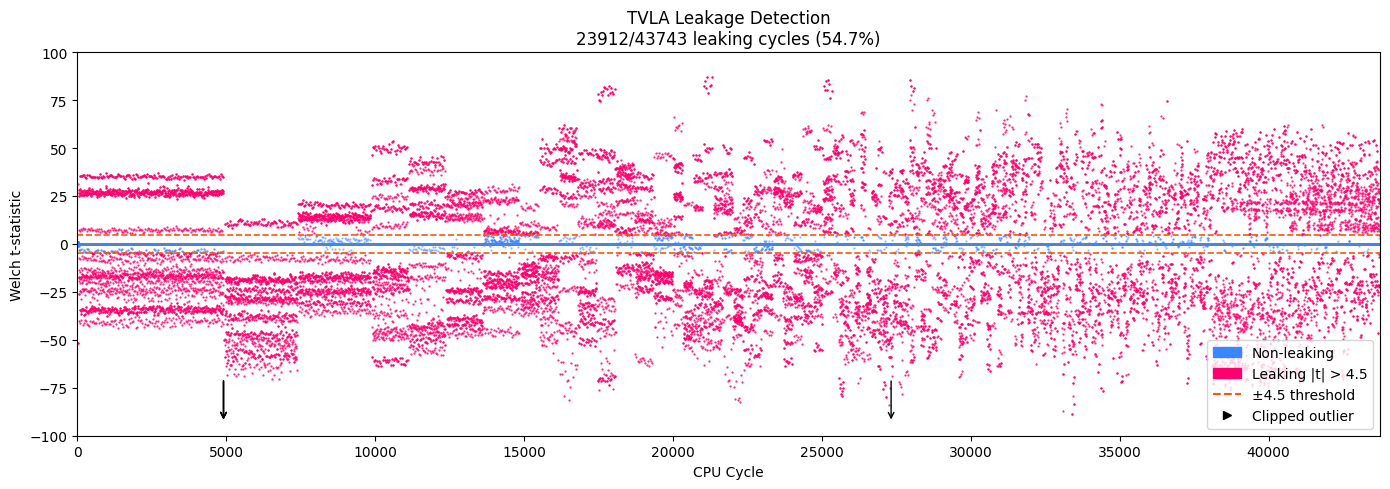

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------

THRESHOLD = 4.5

COL_SAFE   = "#3a86ff"
COL_LEAK   = "#ff006e"
COL_THRESH = "#fb5607"

# -----------------------------------------------------------------------
# Load t-statistics
# -----------------------------------------------------------------------

t_values = np.loadtxt("../ELMO/output_NTT_fvr/fixedvsrandomtstatistics.txt")

cycles    = np.arange(len(t_values))
leaking   = np.abs(t_values) > THRESHOLD
n_leaking = np.sum(leaking)
n_total   = len(t_values)
pct       = 100.0 * n_leaking / n_total
max_abs_t = np.max(np.abs(t_values))

# -----------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------

clip_t  = 100
clipped = np.abs(t_values) > clip_t
in_win  = ~clipped

fig, ax = plt.subplots(figsize=(14, 5))

# Non-leaking points
ax.scatter(
    cycles[in_win & ~leaking],
    t_values[in_win & ~leaking],
    s=0.4,
    color=COL_SAFE,
    alpha=0.5,
    label="Non-leaking"
)

# Leaking points
ax.scatter(
    cycles[in_win & leaking],
    t_values[in_win & leaking],
    s=0.4,
    color=COL_LEAK,
    alpha=0.8,
    label=f"Leaking |t| > {THRESHOLD}"
)

# Outlier arrows
for idx in np.where(clipped)[0]:
    sign = np.sign(t_values[idx])

    ax.annotate(
        "",
        xy=(cycles[idx], sign * clip_t * 0.93),
        xytext=(cycles[idx], sign * clip_t * 0.70),
        arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=1.0
        )
    )

# Threshold lines
ax.axhline( THRESHOLD, color=COL_THRESH, linestyle="--", linewidth=1.2)
ax.axhline(-THRESHOLD, color=COL_THRESH, linestyle="--", linewidth=1.2)
ax.axhline(0, color="grey", linestyle=":", linewidth=0.5)

# Axes
ax.set_xlim(0, n_total)
ax.set_ylim(-clip_t, clip_t)

ax.set_xlabel("CPU Cycle")
ax.set_ylabel("Welch t-statistic")

ax.set_title(
    f"TVLA Leakage Detection\n"
    f"{n_leaking}/{n_total} leaking cycles ({pct:.1f}%)"
)

# Legend
legend_handles = [
    mpatches.Patch(color=COL_SAFE, label="Non-leaking"),
    mpatches.Patch(color=COL_LEAK, label=f"Leaking |t| > {THRESHOLD}"),
    plt.Line2D(
        [0], [0],
        color=COL_THRESH,
        linestyle="--",
        label=f"±{THRESHOLD} threshold"
    ),
    plt.Line2D(
        [0], [0],
        color="black",
        marker=">",
        linestyle="none",
        label="Clipped outlier"
    ),
]

ax.legend(handles=legend_handles, loc="lower right")

ax.legend(handles=legend_handles, loc="lower right")

# IMPORTANT: display inline in Jupyter
plt.tight_layout()
plt.show()

Mean difference

Auto reference length: 43743
Loaded traces: (2000, 43743)
Reference length used: 43743
Fixed: (1000, 43743)
Random: (1000, 43743)


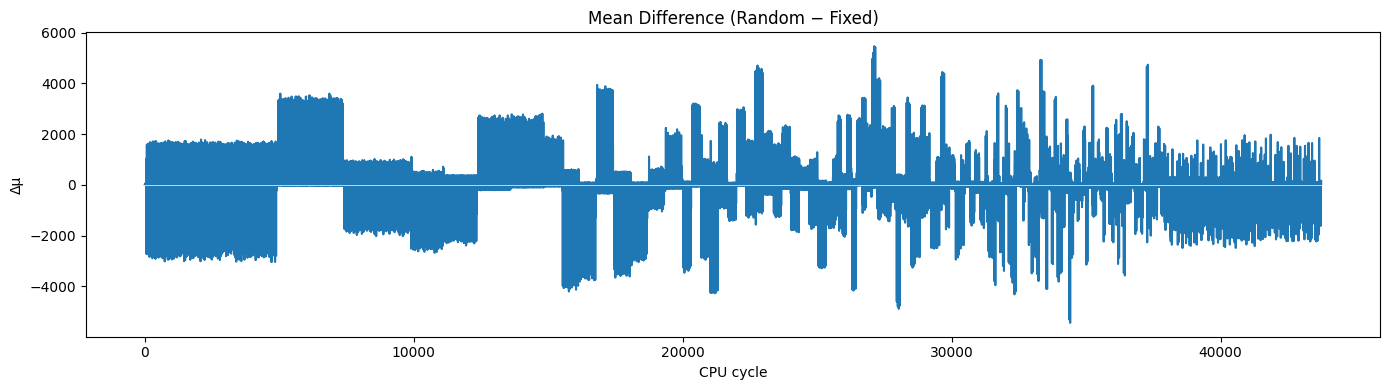

In [37]:
import numpy as np
import glob
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load numeric traces
# ------------------------------------------------------------

import numpy as np
import glob

def load_all_traces(base_path, pattern="trace*.trc", ref_len=None):
    files = sorted(glob.glob(base_path + pattern))

    if len(files) == 0:
        raise ValueError("No trace files found. Check path/pattern.")

    traces = []

    # first pass: load all
    for f in files:
        trace = np.loadtxt(f)
        traces.append(trace)

    # infer reference length if not provided
    if ref_len is None:
        lengths = [len(t) for t in traces]
        ref_len = max(lengths)   # or use min(lengths) if you prefer trimming only
        print("Auto reference length:", ref_len)

    aligned = []
    for t in traces:
        if len(t) > ref_len:
            aligned.append(t[:ref_len])  # trim
        elif len(t) < ref_len:
            aligned.append(np.pad(t, (0, ref_len - len(t))))  # pad
        else:
            aligned.append(t)

    traces = np.array(aligned, dtype=np.float32)

    print("Loaded traces:", traces.shape)
    print("Reference length used:", ref_len)

    return traces


# ------------------------------------------------------------
# Mean difference
# ------------------------------------------------------------

def compute_mean_difference(fixed, random):
    return np.mean(random, axis=0) - np.mean(fixed, axis=0)


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

base = "../ELMO/output_NTT_fvr_NoBinary/traces/"

traces = load_all_traces(base)

fixed = traces[:1000]
random = traces[1000:2000]

print("Fixed:", fixed.shape)
print("Random:", random.shape)

delta_mu = compute_mean_difference(fixed, random)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(14,4))
plt.plot(delta_mu, color="#1f77b4")

plt.axhline(0, color="white", linewidth=0.5)

plt.title("Mean Difference (Random − Fixed)")
plt.xlabel("CPU cycle")
plt.ylabel("Δμ")

plt.tight_layout()
plt.show()

SnR

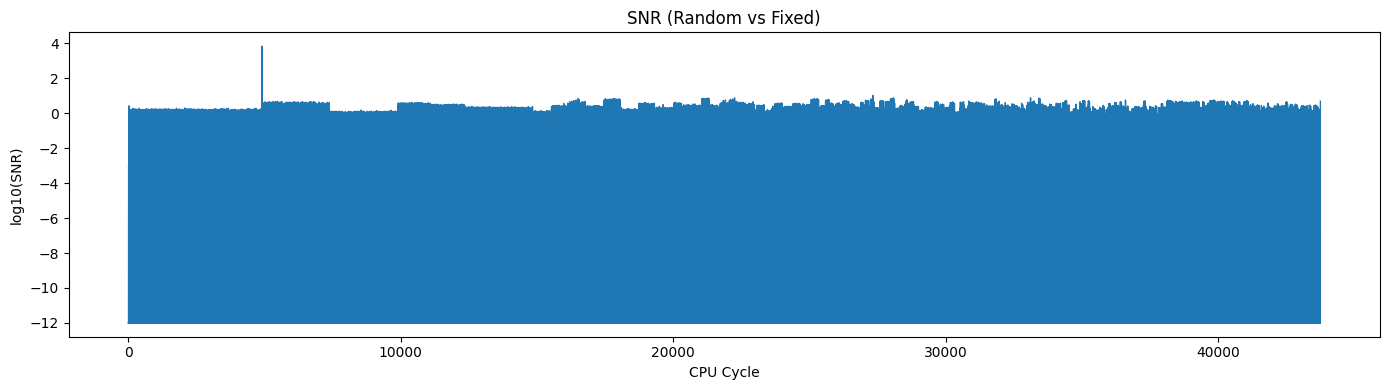

In [38]:
import numpy as np

def compute_snr(fixed, random):
    """
    Per-sample SNR:
    SNR(t) = (mu1 - mu0)^2 / (var1 + var0)
    """

    mu_f = np.mean(fixed, axis=0)
    mu_r = np.mean(random, axis=0)

    var_f = np.var(fixed, axis=0)
    var_r = np.var(random, axis=0)

    numerator = (mu_r - mu_f) ** 2
    denominator = var_f + var_r + 1e-12  # avoid divide-by-zero

    snr = numerator / denominator

    return snr


import matplotlib.pyplot as plt

snr = compute_snr(fixed, random)
snr_log = np.log10(np.abs(snr) + 1e-12)

plt.figure(figsize=(14,4))
plt.plot(snr_log, color="#1f77b4", linewidth=1)

#plt.ylim(-100, 100)
plt.title("SNR (Random vs Fixed)")
plt.xlabel("CPU Cycle")
plt.ylabel("log10(SNR)")

plt.tight_layout()
plt.show()

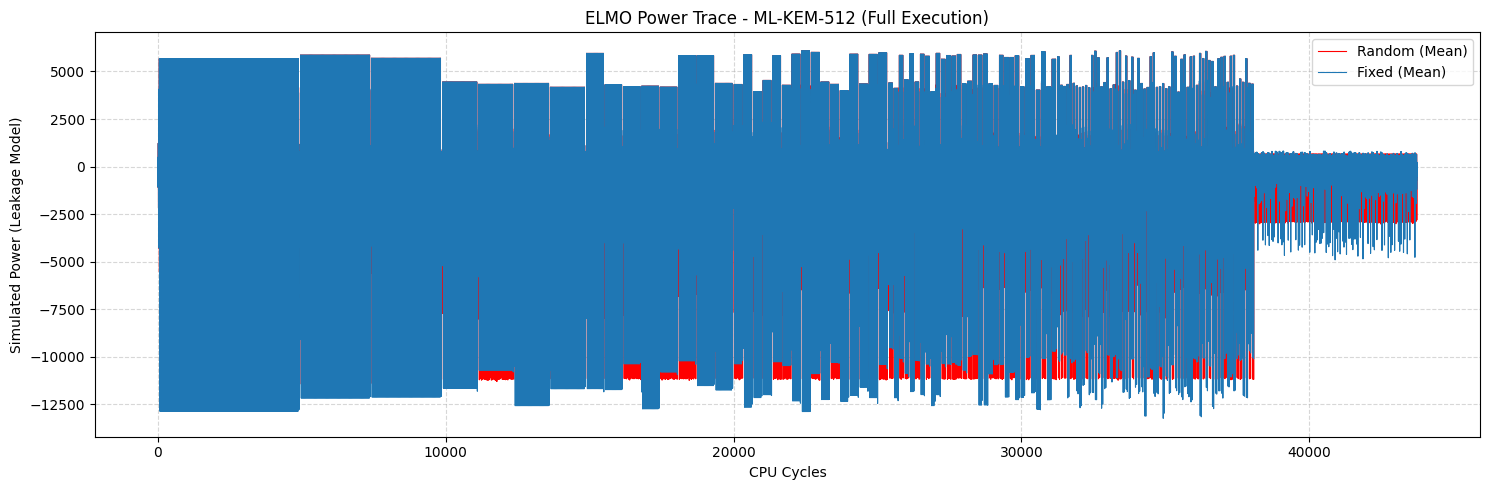

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# If 'random' and 'fixed' are (1000, 43743), 
# we calculate the mean to see the 'average' behavior over the cycles.
mean_random = np.mean(random, axis=0)
mean_fixed = np.mean(fixed, axis=0)

plt.figure(figsize=(15, 5))

# Plotting the means ensures we see the full 43,743 cycles on the X-axis
plt.plot(mean_random, linewidth=0.8, color='red', alpha=1, label='Random (Mean)')
plt.plot(mean_fixed, linewidth=0.8, color='#1f77b4', alpha=1, label='Fixed (Mean)')

# Labeling
plt.title("ELMO Power Trace - ML-KEM-512 (Full Execution)")
plt.xlabel("CPU Cycles")
plt.ylabel("Simulated Power (Leakage Model)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [40]:
import matplotlib.pyplot as plt
import numpy as np

def plot_top_leaky_instructions(t_stats_path, asm_trace_path, top_x=15):
    # 1. Load T-statistics
    # Assuming one T-value per line matching the trace cycles
    t_stats = np.loadtxt(t_stats_path)
    abs_t_stats = np.abs(t_stats)

    # 2. Load and Parse Assembly Instructions
    instructions = []
    with open(asm_trace_path, 'r') as f:
        for line in f:
            # Cleaning the ELMO format: --- 0x0800010A: 0x602E str r6,[r5,#0xE0000004]
            # We want just the instruction part at the end
            if "---" in line:
                parts = line.split(': ')
                if len(parts) > 1:
                    # Extracts 'str r6,[r5,#0xE0000004]' and removes address/opcode
                    instr = parts[-1].strip().split(' ', 1)[-1]
                    instructions.append(instr)
            else:
                instructions.append(line.strip())

    # 3. Pair them up and Sort
    # We use (abs_t, instruction, cycle_index)
    leaky_data = []
    for i in range(min(len(abs_t_stats), len(instructions))):
        leaky_data.append((abs_t_stats[i], instructions[i], i))

    # Sort by leakage magnitude (descending)
    leaky_data.sort(key=lambda x: x[0], reverse=True)
    top_leaky = leaky_data[:top_x]

    # 4. Visualization
    scores = [x[0] for x in top_leaky][::-1]
    labels = [f"Cycle {x[2]}: {x[1]}" for x in top_leaky][::-1]

    plt.figure(figsize=(10, 8))
    bars = plt.barh(labels, scores, color='crimson')
    plt.axvline(x=4.5, color='black', linestyle='--', label='Threshold (|t| > 4.5)')
    
    plt.title(f"Top {top_x} Leakiest Instructions (ML-KEM-512)")
    plt.xlabel("Absolute T-Statistic (|t|)")
    plt.ylabel("Instruction (Cycle: Opcode)")
    plt.legend()
    plt.grid(axis='x', linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Run the function with your paths
# plot_top_leaky_instructions('fixedvsrandomtstatistics.txt', 'asmtrace00001.txt')

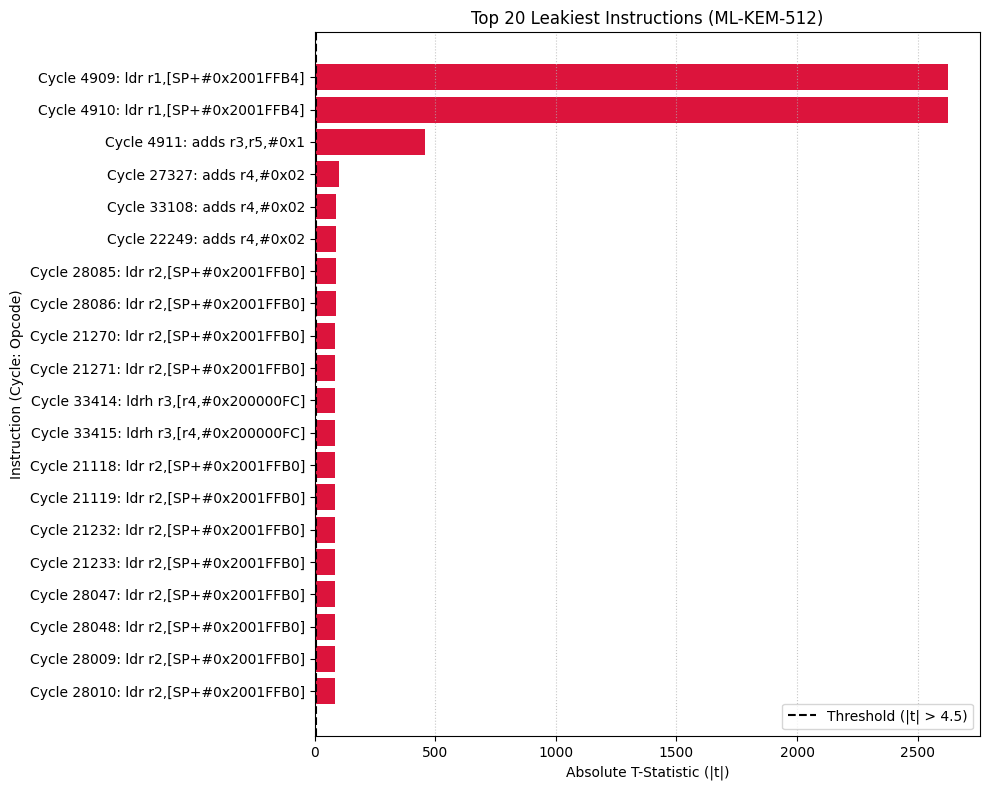

In [41]:
plot_top_leaky_instructions('../ELMO/output_NTT_fvr_NoBinary/fixedvsrandomtstatistics.txt', '../ELMO/output_NTT_fvr_NoBinary/asmoutput/asmtrace00001.txt', 20)

# INTT

### Why such big differences?

Here is some code from NTT.c

NTT:
```
for (j = start; j < start + len; j++) {
    t = fqmul(zeta, r[j + len]);
    r[j + len] = r[j] - t;
    r[j] = r[j] + t;
}
```

INTT:
```
for (j = start; j < start + len; j++) {
    t = r[j];
    r[j] = PQCLEAN_MLKEM512_CLEAN_barrett_reduce(t + r[j + len]);
    r[j + len] = r[j + len] - t;
    r[j + len] = fqmul(zeta, r[j + len]);
}
```
INTT includes a barrett_reduce step inside each butterfly iteration.
This involves several multiplications and shifts to keep the value within the modulus. Adding significantly more instructions and register pressure. 

INTT also has an extra loop at the end
```
const int16_t f = 1441; // mont^2/128
// ... main loops ...

for (j = 0; j < 256; j++) {
    r[j] = fqmul(r[j], f);
}
```
Because this is a simple, linear pass over secret data r[j], it is extremely deterministic.
This translates to zero variance in ELMO

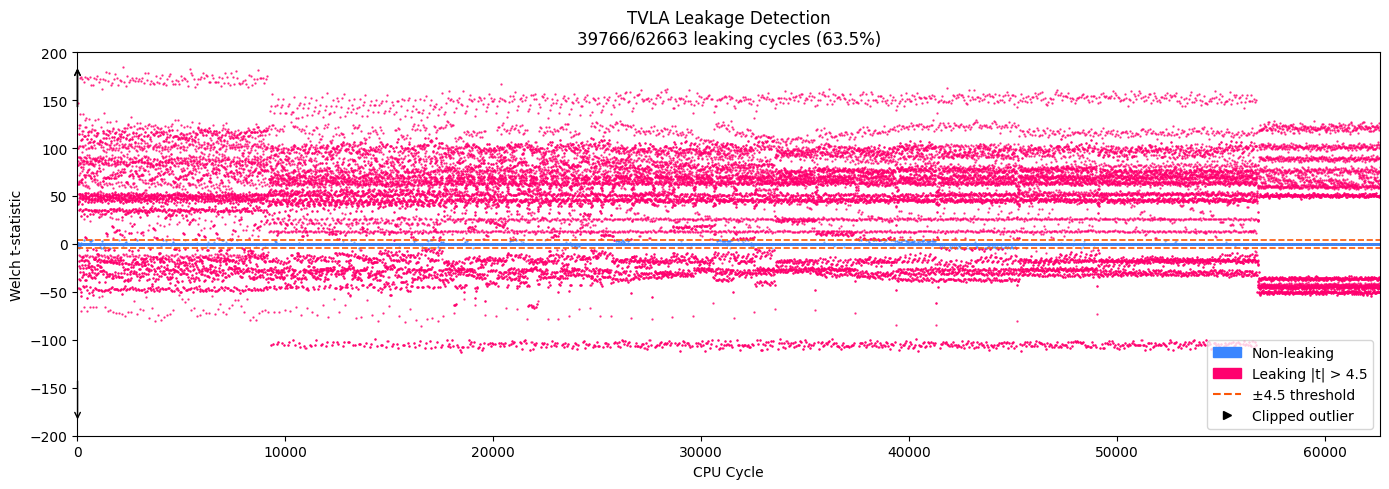

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------

THRESHOLD = 4.5

COL_SAFE   = "#3a86ff"
COL_LEAK   = "#ff006e"
COL_THRESH = "#fb5607"

# -----------------------------------------------------------------------
# Load t-statistics
# -----------------------------------------------------------------------

t_values = np.loadtxt("../ELMO/output_INTT_fvr/fixedvsrandomtstatistics.txt")

cycles    = np.arange(len(t_values))
leaking   = np.abs(t_values) > THRESHOLD
n_leaking = np.sum(leaking)
n_total   = len(t_values)
pct       = 100.0 * n_leaking / n_total
max_abs_t = np.max(np.abs(t_values))

# -----------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------

clip_t  = 200
clipped = np.abs(t_values) > clip_t
in_win  = ~clipped

fig, ax = plt.subplots(figsize=(14, 5))

# Non-leaking points
ax.scatter(
    cycles[in_win & ~leaking],
    t_values[in_win & ~leaking],
    s=0.4,
    color=COL_SAFE,
    alpha=0.5,
    label="Non-leaking"
)

# Leaking points
ax.scatter(
    cycles[in_win & leaking],
    t_values[in_win & leaking],
    s=0.4,
    color=COL_LEAK,
    alpha=0.8,
    label=f"Leaking |t| > {THRESHOLD}"
)

# Outlier arrows
for idx in np.where(clipped)[0]:
    sign = np.sign(t_values[idx])

    ax.annotate(
        "",
        xy=(cycles[idx], sign * clip_t * 0.93),
        xytext=(cycles[idx], sign * clip_t * 0.70),
        arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=1.0
        )
    )

# Threshold lines
ax.axhline( THRESHOLD, color=COL_THRESH, linestyle="--", linewidth=1.2)
ax.axhline(-THRESHOLD, color=COL_THRESH, linestyle="--", linewidth=1.2)
ax.axhline(0, color="grey", linestyle=":", linewidth=0.5)

# Axes
ax.set_xlim(0, n_total)
ax.set_ylim(-clip_t, clip_t)

ax.set_xlabel("CPU Cycle")
ax.set_ylabel("Welch t-statistic")

ax.set_title(
    f"TVLA Leakage Detection\n"
    f"{n_leaking}/{n_total} leaking cycles ({pct:.1f}%)"
)

# Legend
legend_handles = [
    mpatches.Patch(color=COL_SAFE, label="Non-leaking"),
    mpatches.Patch(color=COL_LEAK, label=f"Leaking |t| > {THRESHOLD}"),
    plt.Line2D(
        [0], [0],
        color=COL_THRESH,
        linestyle="--",
        label=f"±{THRESHOLD} threshold"
    ),
    plt.Line2D(
        [0], [0],
        color="black",
        marker=">",
        linestyle="none",
        label="Clipped outlier"
    ),
]

ax.legend(handles=legend_handles, loc="lower right")

ax.legend(handles=legend_handles, loc="lower right")

# IMPORTANT: display inline in Jupyter
plt.tight_layout()
plt.show()

# Montgomery Reduction

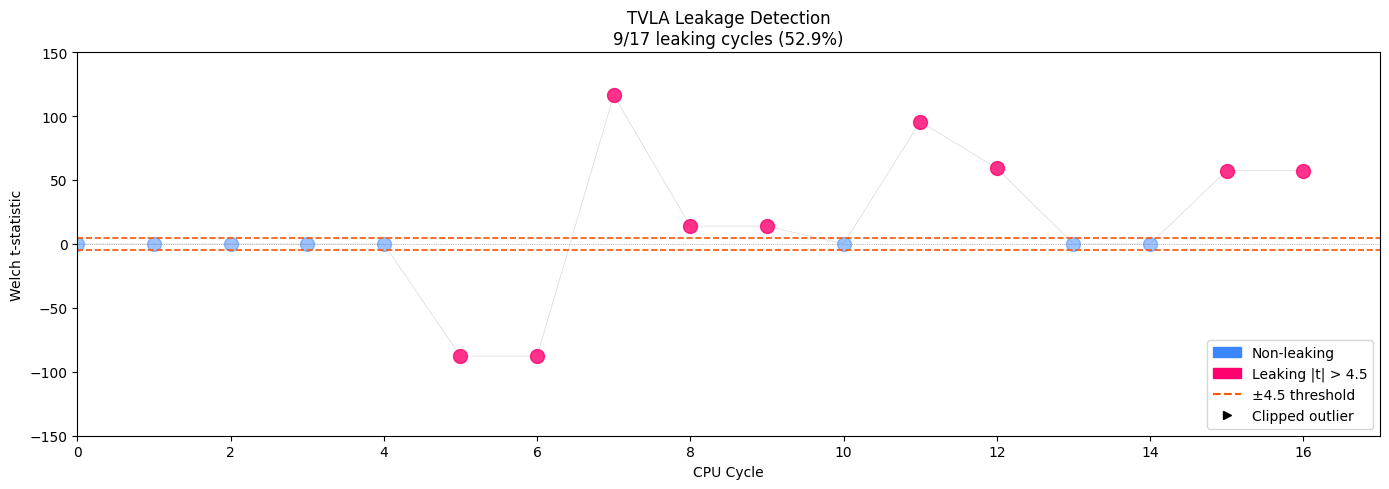

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------

THRESHOLD = 4.5

COL_SAFE   = "#3a86ff"
COL_LEAK   = "#ff006e"
COL_THRESH = "#fb5607"

# -----------------------------------------------------------------------
# Load t-statistics
# -----------------------------------------------------------------------

t_values = np.loadtxt("../ELMO/output_MontgomeryReduce_fvr/fixedvsrandomtstatistics.txt")

cycles    = np.arange(len(t_values))
leaking   = np.abs(t_values) > THRESHOLD
n_leaking = np.sum(leaking)
n_total   = len(t_values)
pct       = 100.0 * n_leaking / n_total
max_abs_t = np.max(np.abs(t_values))

# -----------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------

clip_t  = 150
clipped = np.abs(t_values) > clip_t
in_win  = ~clipped

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    cycles[in_win], 
    t_values[in_win], 
    color="grey", 
    lw=0.5, 
    alpha=0.3, 
    zorder=1
)

# Non-leaking points
ax.scatter(
    cycles[in_win & ~leaking],
    t_values[in_win & ~leaking],
    s=100,
    color=COL_SAFE,
    alpha=0.5,
    label="Non-leaking"
)

# Leaking points
ax.scatter(
    cycles[in_win & leaking],
    t_values[in_win & leaking],
    s=100,
    color=COL_LEAK,
    alpha=0.8,
    label=f"Leaking |t| > {THRESHOLD}"
)

# Outlier arrows
for idx in np.where(clipped)[0]:
    sign = np.sign(t_values[idx])

    ax.annotate(
        "",
        xy=(cycles[idx], sign * clip_t * 0.93),
        xytext=(cycles[idx], sign * clip_t * 0.70),
        arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=1.0
        )
    )

# Threshold lines
ax.axhline( THRESHOLD, color=COL_THRESH, linestyle="--", linewidth=1.2)
ax.axhline(-THRESHOLD, color=COL_THRESH, linestyle="--", linewidth=1.2)
ax.axhline(0, color="grey", linestyle=":", linewidth=0.5)

# Axes
ax.set_xlim(0, n_total)
ax.set_ylim(-clip_t, clip_t)

ax.set_xlabel("CPU Cycle")
ax.set_ylabel("Welch t-statistic")

ax.set_title(
    f"TVLA Leakage Detection\n"
    f"{n_leaking}/{n_total} leaking cycles ({pct:.1f}%)"
)

# Legend
legend_handles = [
    mpatches.Patch(color=COL_SAFE, label="Non-leaking"),
    mpatches.Patch(color=COL_LEAK, label=f"Leaking |t| > {THRESHOLD}"),
    plt.Line2D(
        [0], [0],
        color=COL_THRESH,
        linestyle="--",
        label=f"±{THRESHOLD} threshold"
    ),
    plt.Line2D(
        [0], [0],
        color="black",
        marker=">",
        linestyle="none",
        label="Clipped outlier"
    ),
]

ax.legend(handles=legend_handles, loc="lower right")

ax.legend(handles=legend_handles, loc="lower right")

# IMPORTANT: display inline in Jupyter
plt.tight_layout()
plt.show()

# Decapsulation

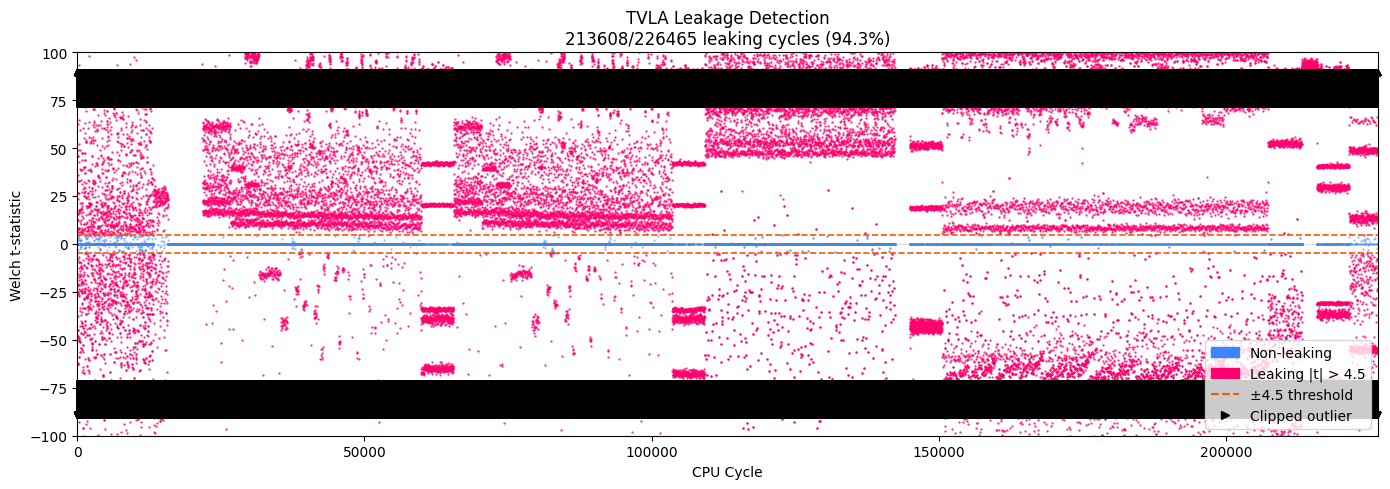

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------

THRESHOLD = 4.5

COL_SAFE   = "#3a86ff"
COL_LEAK   = "#ff006e"
COL_THRESH = "#fb5607"

# -----------------------------------------------------------------------
# Load t-statistics
# -----------------------------------------------------------------------

t_values = np.loadtxt("../ELMO/output_decaps_fvr/fixedvsrandomtstatistics.txt")

cycles    = np.arange(len(t_values))
leaking   = np.abs(t_values) > THRESHOLD
n_leaking = np.sum(leaking)
n_total   = len(t_values)
pct       = 100.0 * n_leaking / n_total
max_abs_t = np.max(np.abs(t_values))

# -----------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------

clip_t  = 100
clipped = np.abs(t_values) > clip_t
in_win  = ~clipped

fig, ax = plt.subplots(figsize=(14, 5))

# Non-leaking points
ax.scatter(
    cycles[in_win & ~leaking],
    t_values[in_win & ~leaking],
    s=0.4,
    color=COL_SAFE,
    alpha=0.5,
    label="Non-leaking"
)

# Leaking points
ax.scatter(
    cycles[in_win & leaking],
    t_values[in_win & leaking],
    s=0.4,
    color=COL_LEAK,
    alpha=0.8,
    label=f"Leaking |t| > {THRESHOLD}"
)

# Outlier arrows
for idx in np.where(clipped)[0]:
    sign = np.sign(t_values[idx])

    ax.annotate(
        "",
        xy=(cycles[idx], sign * clip_t * 0.93),
        xytext=(cycles[idx], sign * clip_t * 0.70),
        arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=1.0
        )
    )

# Threshold lines
ax.axhline( THRESHOLD, color=COL_THRESH, linestyle="--", linewidth=1.2)
ax.axhline(-THRESHOLD, color=COL_THRESH, linestyle="--", linewidth=1.2)
ax.axhline(0, color="grey", linestyle=":", linewidth=0.5)

# Axes
ax.set_xlim(0, n_total)
ax.set_ylim(-clip_t, clip_t)

ax.set_xlabel("CPU Cycle")
ax.set_ylabel("Welch t-statistic")

ax.set_title(
    f"TVLA Leakage Detection\n"
    f"{n_leaking}/{n_total} leaking cycles ({pct:.1f}%)"
)

# Legend
legend_handles = [
    mpatches.Patch(color=COL_SAFE, label="Non-leaking"),
    mpatches.Patch(color=COL_LEAK, label=f"Leaking |t| > {THRESHOLD}"),
    plt.Line2D(
        [0], [0],
        color=COL_THRESH,
        linestyle="--",
        label=f"±{THRESHOLD} threshold"
    ),
    plt.Line2D(
        [0], [0],
        color="black",
        marker=">",
        linestyle="none",
        label="Clipped outlier"
    ),
]

ax.legend(handles=legend_handles, loc="lower right")

ax.legend(handles=legend_handles, loc="lower right")

# IMPORTANT: display inline in Jupyter
plt.tight_layout()
plt.show()

Leaking cycles (|t| > 3.5, excluding NaN/Inf): 52419
Max sane |t|: 199.0


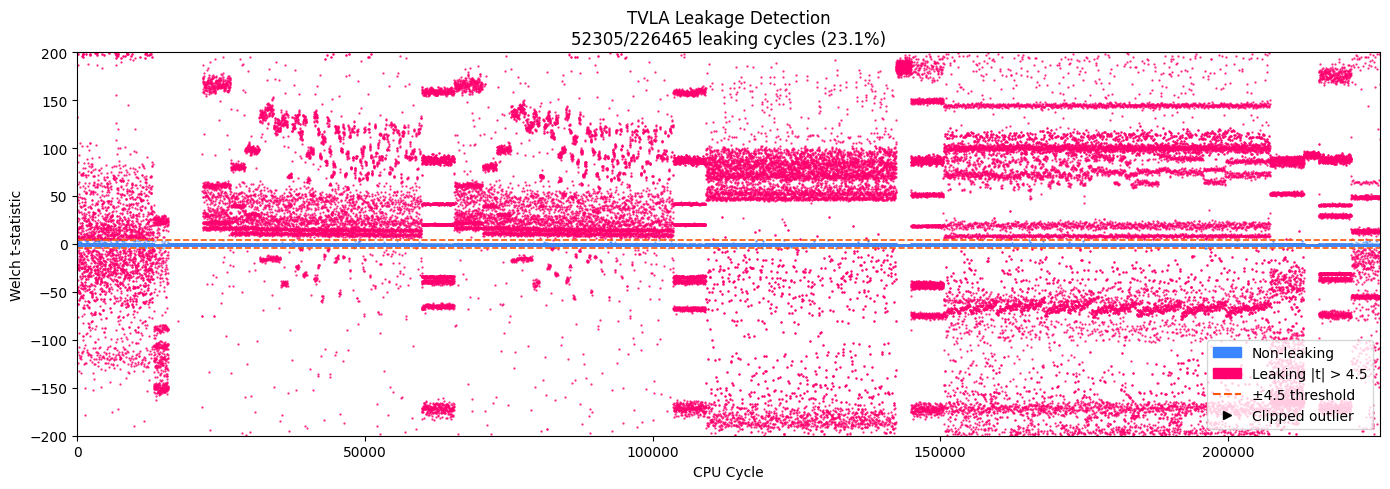

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------

THRESHOLD = 4.5

COL_SAFE   = "#3a86ff"
COL_LEAK   = "#ff006e"
COL_THRESH = "#fb5607"

# -----------------------------------------------------------------------
# Load t-statistics
# -----------------------------------------------------------------------

t = np.loadtxt('../ELMO/output_decaps_fvr/fixedvsrandomtstatistics.txt')

# Also load traces to compute per-cycle variance (or do it from ELMO's traces)
# Quick fix: just clamp infinities and NaN
t_clean = np.where(np.isfinite(t), t, -1.0)

# Better: filter by magnitude — real leakage never exceeds ~99 with 1000 traces
clip_t  = 200
SANE_LIMIT = clip_t - 1
t_sane = np.where(np.abs(t_clean) < SANE_LIMIT, t_clean, -1.0)

n_leaking = np.sum(np.abs(t_sane) > 3.5)
print(f"Leaking cycles (|t| > 3.5, excluding NaN/Inf): {n_leaking}")
print(f"Max sane |t|: {np.max(np.abs(t_sane)):.1f}")
t_values = t_sane

cycles    = np.arange(len(t_values))
leaking   = np.abs(t_values) > THRESHOLD
n_leaking = np.sum(leaking)
n_total   = len(t_values)
pct       = 100.0 * n_leaking / n_total
max_abs_t = np.max(np.abs(t_values))

# -----------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------

clipped = np.abs(t_values) > clip_t
in_win  = ~clipped

fig, ax = plt.subplots(figsize=(14, 5))

# Non-leaking points
ax.scatter(
    cycles[in_win & ~leaking],
    t_values[in_win & ~leaking],
    s=0.4,
    color=COL_SAFE,
    alpha=0.5,
    label="Non-leaking"
)

# Leaking points
ax.scatter(
    cycles[in_win & leaking],
    t_values[in_win & leaking],
    s=0.4,
    color=COL_LEAK,
    alpha=0.8,
    label=f"Leaking |t| > {THRESHOLD}"
)

# Outlier arrows
for idx in np.where(clipped)[0]:
    sign = np.sign(t_values[idx])

    ax.annotate(
        "",
        xy=(cycles[idx], sign * clip_t * 0.93),
        xytext=(cycles[idx], sign * clip_t * 0.70),
        arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=1.0
        )
    )

# Threshold lines
ax.axhline( THRESHOLD, color=COL_THRESH, linestyle="--", linewidth=1.2)
ax.axhline(-THRESHOLD, color=COL_THRESH, linestyle="--", linewidth=1.2)
ax.axhline(0, color="grey", linestyle=":", linewidth=0.5)

# Axes
ax.set_xlim(0, n_total)
ax.set_ylim(-clip_t, clip_t)

ax.set_xlabel("CPU Cycle")
ax.set_ylabel("Welch t-statistic")

ax.set_title(
    f"TVLA Leakage Detection\n"
    f"{n_leaking}/{n_total} leaking cycles ({pct:.1f}%)"
)

# Legend
legend_handles = [
    mpatches.Patch(color=COL_SAFE, label="Non-leaking"),
    mpatches.Patch(color=COL_LEAK, label=f"Leaking |t| > {THRESHOLD}"),
    plt.Line2D(
        [0], [0],
        color=COL_THRESH,
        linestyle="--",
        label=f"±{THRESHOLD} threshold"
    ),
    plt.Line2D(
        [0], [0],
        color="black",
        marker=">",
        linestyle="none",
        label="Clipped outlier"
    ),
]

ax.legend(handles=legend_handles, loc="lower right")

ax.legend(handles=legend_handles, loc="lower right")

# IMPORTANT: display inline in Jupyter
plt.tight_layout()
plt.show()

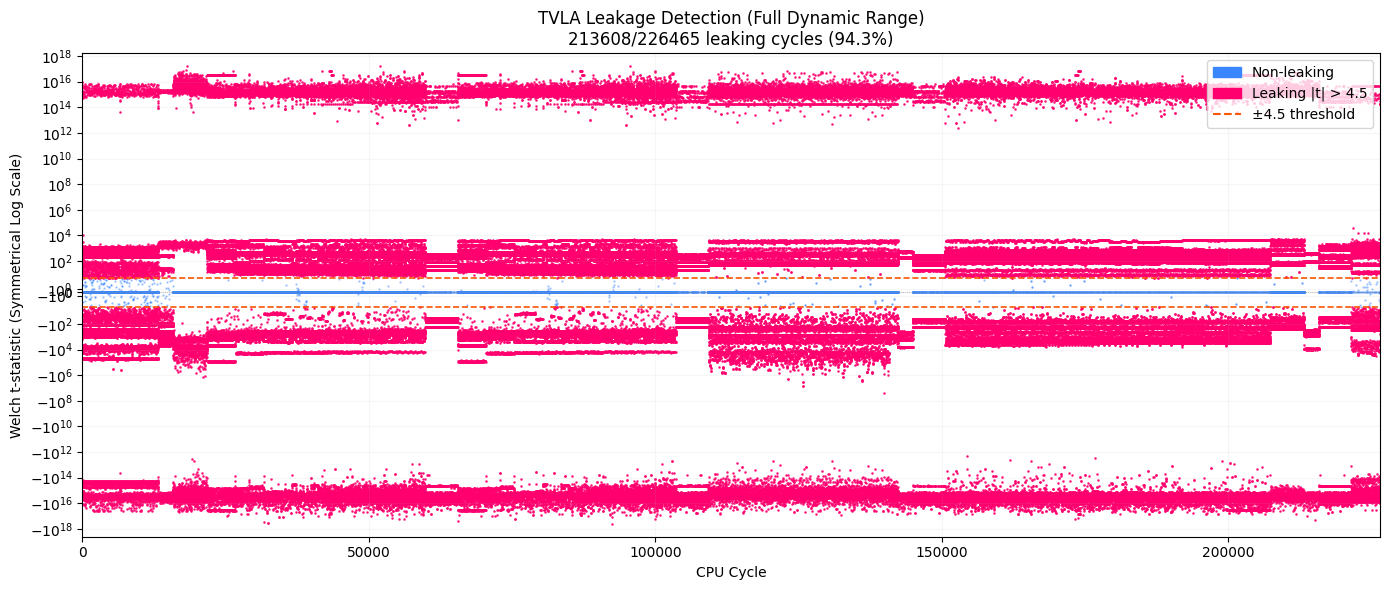

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------------------------------------------------
# Load t-statistics
# -----------------------------------------------------------------------
# Load original data without manual clipping
t_values = np.loadtxt('../ELMO/output_decaps_fvr/fixedvsrandomtstatistics.txt')

# Handle actual NaNs which can break the plotter
t_values = np.nan_to_num(t_values, nan=0.0)

cycles = np.arange(len(t_values))

# -----------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------
THRESHOLD = 4.5
COL_SAFE   = "#3a86ff"
COL_LEAK   = "#ff006e"
COL_THRESH = "#fb5607"

leaking   = np.abs(t_values) > THRESHOLD
n_leaking = np.sum(leaking)
n_total   = len(t_values)
pct       = 100.0 * n_leaking / n_total

# -----------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))

# Set the scale to SymLog
# linthresh: values between -4.5 and 4.5 will be plotted linearly
# linscale: controls the visual size of the linear region relative to the log region
ax.set_yscale('symlog', linthresh=THRESHOLD, linscale=1.0)

# Non-leaking points (Linear region)
ax.scatter(
    cycles[~leaking],
    t_values[~leaking],
    s=0.5,
    color=COL_SAFE,
    alpha=0.4,
    label="Non-leaking"
)

# Leaking points (Transitioning into Log region)
ax.scatter(
    cycles[leaking],
    t_values[leaking],
    s=0.8,
    color=COL_LEAK,
    alpha=0.8,
    label=f"Leaking |t| > {THRESHOLD}"
)

# Threshold lines
ax.axhline( THRESHOLD, color=COL_THRESH, linestyle="--", linewidth=1.2)
ax.axhline(-THRESHOLD, color=COL_THRESH, linestyle="--", linewidth=1.2)
ax.axhline(0, color="grey", linestyle=":", linewidth=0.5)

# Axes formatting
ax.set_xlim(0, n_total)

# Set Y-limit to accommodate the 10^17 values
ax.set_ylim(t_values.min() * 10, t_values.max() * 10) 

ax.set_xlabel("CPU Cycle")
ax.set_ylabel("Welch t-statistic (Symmetrical Log Scale)")

ax.set_title(
    f"TVLA Leakage Detection (Full Dynamic Range)\n"
    f"{n_leaking}/{n_total} leaking cycles ({pct:.1f}%)"
)

# Grid lines help visualize the log jumps (10, 100, 1000...)
ax.grid(True, which="both", ls="-", alpha=0.1)

# Legend
legend_handles = [
    mpatches.Patch(color=COL_SAFE, label="Non-leaking"),
    mpatches.Patch(color=COL_LEAK, label=f"Leaking |t| > {THRESHOLD}"),
    plt.Line2D([0], [0], color=COL_THRESH, linestyle="--", label=f"±{THRESHOLD} threshold")
]
ax.legend(handles=legend_handles, loc="upper right")

plt.tight_layout()
plt.show()

<>:67: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:67: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/tmp/ipykernel_2716502/3533091033.py:67: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax.set_ylabel("Welch t-statistic (Clipped $\pm10^4$)")


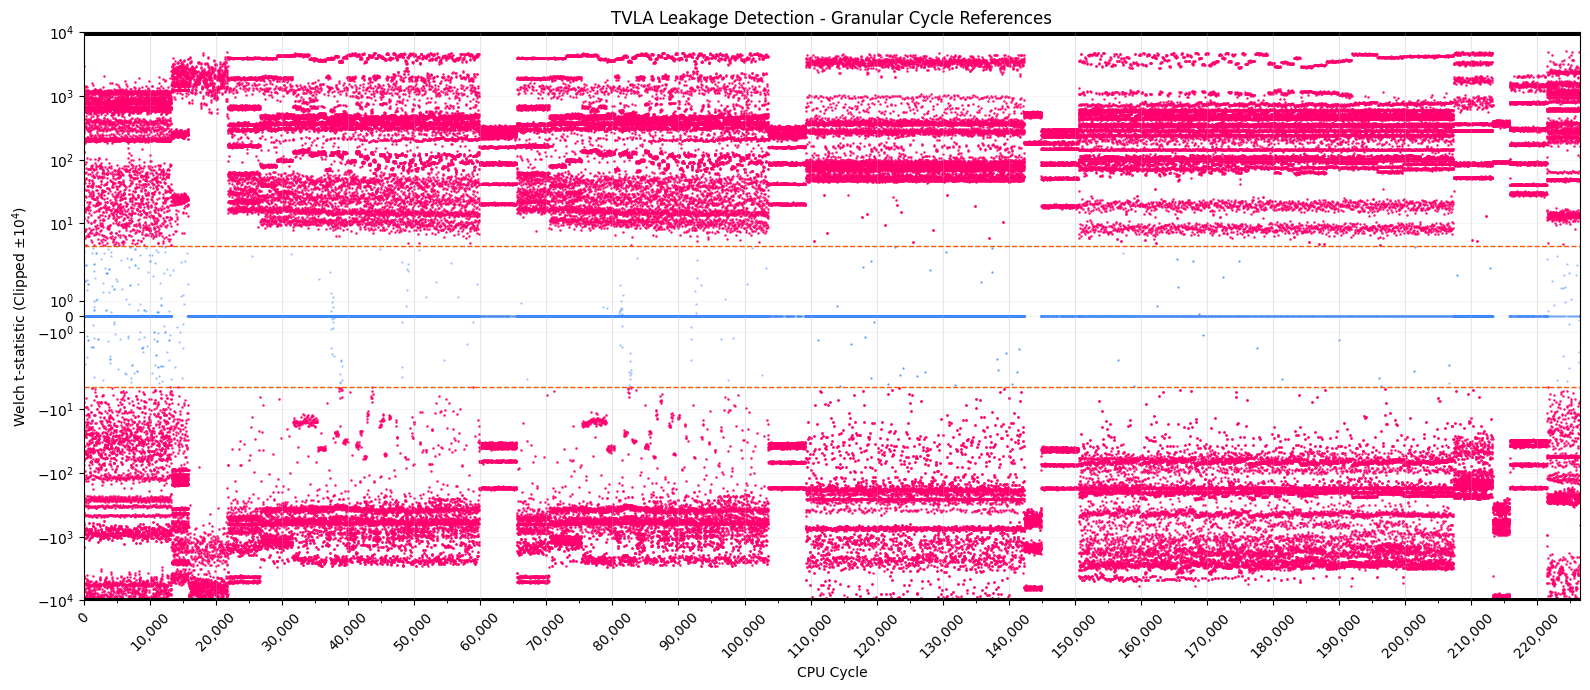

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

# -----------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------
THRESHOLD = 4.5
CLIP_VAL = 1e4 

COL_SAFE   = "#3a86ff"
COL_LEAK   = "#ff006e"
COL_THRESH = "#fb5607"

# -----------------------------------------------------------------------
# Load t-statistics
# -----------------------------------------------------------------------
t_values = np.loadtxt('../ELMO/output_decaps_fvr/fixedvsrandomtstatistics.txt')
t_values = np.nan_to_num(t_values, nan=0.0)
cycles = np.arange(len(t_values))

leaking = np.abs(t_values) > THRESHOLD
n_total = len(t_values)

# -----------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 7)) # Slightly wider for more ticks

# 1. Set the Scale and Limits
ax.set_yscale('symlog', linthresh=THRESHOLD, linscale=1.0)
ax.set_ylim(-CLIP_VAL, CLIP_VAL)
ax.set_xlim(0, n_total)

# 2. Configure X-axis Ticks (Every 10,000 cycles)
# Major ticks every 10,000
ax.xaxis.set_major_locator(ticker.MultipleLocator(10000))
# Minor ticks every 5,000 (optional)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5000))

# Format numbers with commas (e.g., 10,000 instead of 10000)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Rotate labels so they don't overlap if the trace is long
plt.xticks(rotation=45)

# 3. Scatter Plots
ax.scatter(cycles[~leaking], t_values[~leaking], s=0.5, color=COL_SAFE, alpha=0.4)
ax.scatter(cycles[leaking], t_values[leaking], s=0.8, color=COL_LEAK, alpha=0.8)

# 4. Markers for clipped values (10^18 spikes)
is_clipped_pos = t_values > CLIP_VAL
is_clipped_neg = t_values < -CLIP_VAL
ax.scatter(cycles[is_clipped_pos], [CLIP_VAL * 0.98] * np.sum(is_clipped_pos), 
           marker='^', color='black', s=5, alpha=0.5)
ax.scatter(cycles[is_clipped_neg], [-CLIP_VAL * 0.98] * np.sum(is_clipped_neg), 
           marker='v', color='black', s=5, alpha=0.5)

# 5. Styling
ax.axhline(THRESHOLD, color=COL_THRESH, linestyle="--", linewidth=1)
ax.axhline(-THRESHOLD, color=COL_THRESH, linestyle="--", linewidth=1)
ax.grid(True, which="major", axis='x', ls="-", alpha=0.3) # Show vertical lines for every 10k
ax.grid(True, which="major", axis='y', ls="-", alpha=0.1)

ax.set_xlabel("CPU Cycle")
ax.set_ylabel("Welch t-statistic (Clipped $\pm10^4$)")
ax.set_title(f"TVLA Leakage Detection - Granular Cycle References")

plt.tight_layout()
plt.show()